In [ ]:
#ImPORTATION LIBRAIRIES 

import numpy as np
import  pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# import

from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report

In [ ]:
#importonse

data = pd.read_csv('brain_stroke.csv')
data.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
2,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
3,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
4,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1


In [ ]:
#Colonnes

data.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')

In [ ]:
#lignes dupliquées

data.duplicated().value_counts()

False    4981
Name: count, dtype: int64

In [8]:
#types des donnees des differentes colonnes du dataset

data.dtypes

gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object

In [9]:
# LISTONS LE NOMBRE DE VALEURS NULLES PAR COLONNES

data.isnull().sum()

gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

In [10]:
#changeons le type de la colonne age en entier

data.age = data.age.apply(lambda x:int(x))
data.dtypes

gender                object
age                    int64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object

In [11]:
data.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Male,80,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
2,Female,49,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
3,Female,79,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
4,Male,81,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1


In [12]:
num_col= ['age','avg_glucose_level','bmi']
cat_col=['gender','hypertension','heart_disease','ever_married','work_type','Residence_type','smoking_status','stroke']

<Axes: >

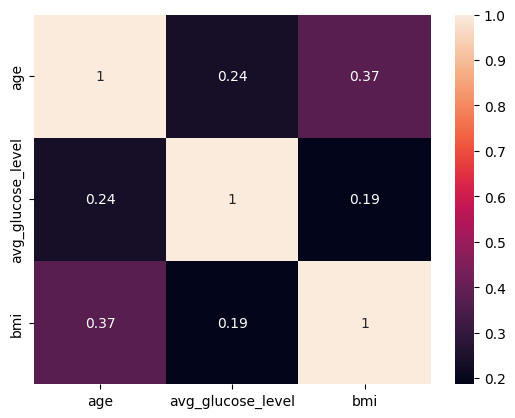

In [13]:
#correlation entre les colonnes numeriques

df =data[['age','avg_glucose_level','bmi']]

df.corr()
sns.heatmap(df.corr(), annot=True)

In [14]:
cat_col=['gender','hypertension','heart_disease','ever_married','work_type','Residence_type','smoking_status','stroke']

In [15]:
# DIFFERENTES CATEGORIES PRESENTES
for i in cat_col:
    print(data[i].unique())


['Male' 'Female']
[0 1]
[1 0]
['Yes' 'No']
['Private' 'Self-employed' 'Govt_job' 'children']
['Urban' 'Rural']
['formerly smoked' 'never smoked' 'smokes' 'Unknown']
[1 0]


In [16]:
# PROPORTION DE CHAQUE CATEGORIE
for i in cat_col:
    print(data[i].value_counts())


gender
Female    2907
Male      2074
Name: count, dtype: int64
hypertension
0    4502
1     479
Name: count, dtype: int64
heart_disease
0    4706
1     275
Name: count, dtype: int64
ever_married
Yes    3280
No     1701
Name: count, dtype: int64
work_type
Private          2860
Self-employed     804
children          673
Govt_job          644
Name: count, dtype: int64
Residence_type
Urban    2532
Rural    2449
Name: count, dtype: int64
smoking_status
never smoked       1838
Unknown            1500
formerly smoked     867
smokes              776
Name: count, dtype: int64
stroke
0    4733
1     248
Name: count, dtype: int64


In [17]:
data.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Male,80,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
2,Female,49,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
3,Female,79,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
4,Male,81,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1


In [18]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data.gender =le.fit_transform(data.gender)
data.ever_married =le.fit_transform(data.ever_married)
data.Residence_type =le.fit_transform(data.Residence_type)
data

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1,67,0,1,1,Private,1,228.69,36.6,formerly smoked,1
1,1,80,0,1,1,Private,0,105.92,32.5,never smoked,1
2,0,49,0,0,1,Private,1,171.23,34.4,smokes,1
3,0,79,1,0,1,Self-employed,0,174.12,24.0,never smoked,1
4,1,81,0,0,1,Private,1,186.21,29.0,formerly smoked,1
...,...,...,...,...,...,...,...,...,...,...,...
4976,1,41,0,0,0,Private,0,70.15,29.8,formerly smoked,0
4977,1,40,0,0,1,Private,1,191.15,31.1,smokes,0
4978,0,45,1,0,1,Govt_job,0,95.02,31.8,smokes,0
4979,1,40,0,0,1,Private,0,83.94,30.0,smokes,0


In [19]:
fe = data.groupby('work_type').size()/len(data)
fe1 = data.groupby('smoking_status').size()/len(data)
data.loc[:,'work']=data.work_type.map(fe)
data.loc[:,'smoking']=data.smoking_status.map(fe1)
data


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,work,smoking
0,1,67,0,1,1,Private,1,228.69,36.6,formerly smoked,1,0.574182,0.174061
1,1,80,0,1,1,Private,0,105.92,32.5,never smoked,1,0.574182,0.369002
2,0,49,0,0,1,Private,1,171.23,34.4,smokes,1,0.574182,0.155792
3,0,79,1,0,1,Self-employed,0,174.12,24.0,never smoked,1,0.161413,0.369002
4,1,81,0,0,1,Private,1,186.21,29.0,formerly smoked,1,0.574182,0.174061
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4976,1,41,0,0,0,Private,0,70.15,29.8,formerly smoked,0,0.574182,0.174061
4977,1,40,0,0,1,Private,1,191.15,31.1,smokes,0,0.574182,0.155792
4978,0,45,1,0,1,Govt_job,0,95.02,31.8,smokes,0,0.129291,0.155792
4979,1,40,0,0,1,Private,0,83.94,30.0,smokes,0,0.574182,0.155792


In [20]:
# Supprimons les colonnes non codes et gardons celles codes

data.drop('work_type',axis=1,inplace=True)

In [21]:
data.drop('smoking_status',axis=1,inplace=True)

In [22]:
data

,gender,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,stroke,work,smoking
0,1,67,0,1,1,1,228.69,36.6,1,0.574182,0.174061
1,1,80,0,1,1,0,105.92,32.5,1,0.574182,0.369002
2,0,49,0,0,1,1,171.23,34.4,1,0.574182,0.155792
3,0,79,1,0,1,0,174.12,24.0,1,0.161413,0.369002
4,1,81,0,0,1,1,186.21,29.0,1,0.574182,0.174061
...,...,...,...,...,...,...,...,...,...,...,...
4976,1,41,0,0,0,0,70.15,29.8,0,0.574182,0.174061
4977,1,40,0,0,1,1,191.15,31.1,0,0.574182,0.155792
4978,0,45,1,0,1,0,95.02,31.8,0,0.129291,0.155792
4979,1,40,0,0,1,0,83.94,30.0,0,0.574182,0.155792


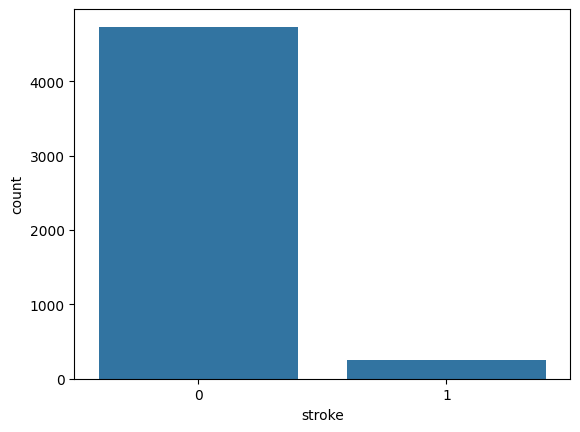

In [23]:
cat_col=['gender','hypertension','heart_disease','ever_married','work_type','Residence_type','smoking_status','stroke']

sns.countplot(x = 'stroke', data = data);

In [24]:
num_col= ['age','avg_glucose_level','bmi']

    #CALCUL DES Q1,Q3,IQR,SUP et INF 

for i in num_col:


    Q3 = np.percentile(data[i],75)  # Premier Quartile
    Q1 = np.percentile(data[i],25)   #Troisieme Quartile  
    
    IQR = Q3 - Q1   # IQR : intervalle inter quartile

    INF_Q1 =  Q1 - 1.5*IQR    #Borne Inferieure
    SUP_Q3 =  Q3 + 1.5*IQR    #Borne Superieure

    print('LE PREMIER QUARTILE DE', i,'est Q1= ', Q1)
    print('LE TROISIEME QUARTILE DE', i,'est Q3= ', Q3)
    print('LINTERVALLE INTERQUARTILE DE', i,'est IQR= ', IQR)
    print('LE BORNE SUPERIEURE DE', i,'est SUP= ', SUP_Q3)
    print('LA BORNE INFERIEURE DE', i,'est INF= ', INF_Q1)
    print('=========================================')

LE PREMIER QUARTILE DE age est Q1=  25.0
LE TROISIEME QUARTILE DE age est Q3=  61.0
LINTERVALLE INTERQUARTILE DE age est IQR=  36.0
LE BORNE SUPERIEURE DE age est SUP=  115.0
LA BORNE INFERIEURE DE age est INF=  -29.0
LE PREMIER QUARTILE DE avg_glucose_level est Q1=  77.23
LE TROISIEME QUARTILE DE avg_glucose_level est Q3=  113.86
LINTERVALLE INTERQUARTILE DE avg_glucose_level est IQR=  36.629999999999995
LE BORNE SUPERIEURE DE avg_glucose_level est SUP=  168.805
LA BORNE INFERIEURE DE avg_glucose_level est INF=  22.28500000000001
LE PREMIER QUARTILE DE bmi est Q1=  23.7
LE TROISIEME QUARTILE DE bmi est Q3=  32.6
LINTERVALLE INTERQUARTILE DE bmi est IQR=  8.900000000000002
LE BORNE SUPERIEURE DE bmi est SUP=  45.95
LA BORNE INFERIEURE DE bmi est INF=  10.349999999999996


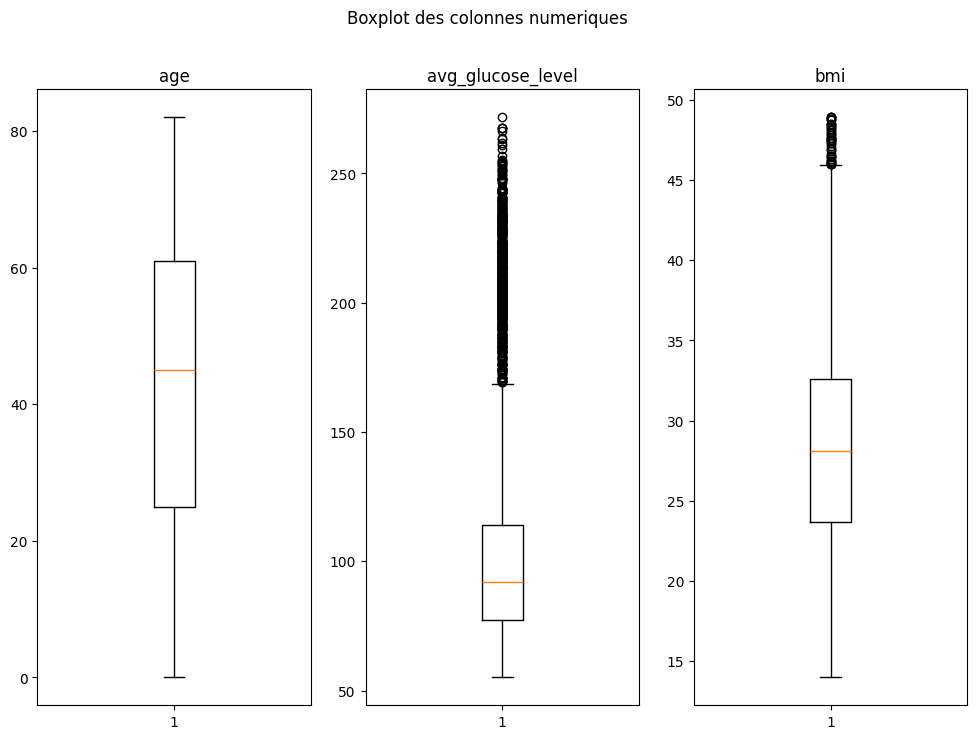

In [25]:
num_col= ['age','avg_glucose_level','bmi']
fig, ax = plt.subplots(1,3,figsize=(12,8))

for j in range(3):
    ax[j].boxplot(data[num_col[j]])
    ax[j].set_title(num_col[j])

fig.suptitle("Boxplot des colonnes numeriques")
plt.show()

In [26]:
num_col= ['age','avg_glucose_level','bmi']

for i in num_col:

    Q3 = np.percentile(data[i],75)
    Q1 = np.percentile(data[i],25)
    IQR = Q3 - Q1
    Maxi = Q3 + 1.5*IQR
    Mini = Q1 - 1.5*IQR

#Ramenons les outliers a la distriution 

    data[i][data[i] > Maxi] = Maxi
    data[i][data[i] < Mini] = Mini

C:\Users\COMPUTER CARE\AppData\Local\Temp\ipykernel_17416\1571256442.py:13: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  data[i][data[i] > Maxi] = Maxi
C:\Users\COMPUTER CARE\AppData\Local\Temp\ipykernel_17416\1571256442.py:13: SettingWithC

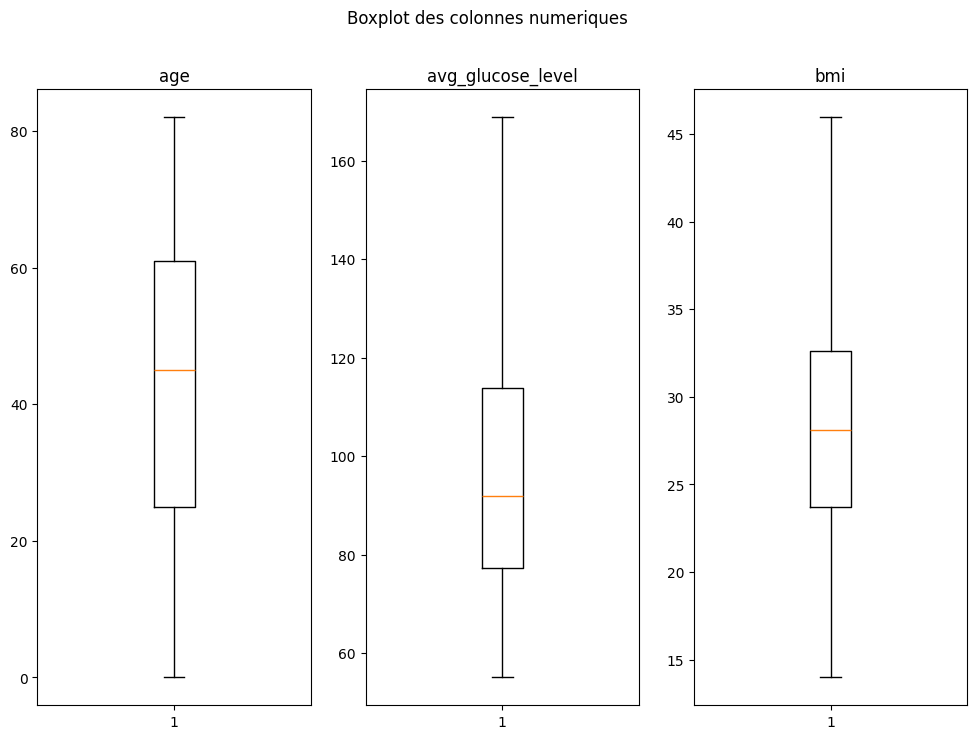

In [27]:
fig, ax = plt.subplots(1,3,figsize=(12,8))

for j in range(3):
    ax[j].boxplot(data[num_col[j]])
    ax[j].set_title(num_col[j])

fig.suptitle("Boxplot des colonnes numeriques")
plt.show()

In [28]:
# caracteristiques du dataset

data.describe().T # transpose

,count,mean,std,min,25%,50%,75%,max
gender,4981.0,0.416382,0.493008,0.000000,0.000000,0.000000,1.000000,1.000000
age,4981.0,43.408552,22.683945,0.000000,25.000000,45.000000,61.000000,82.000000
hypertension,4981.0,0.096165,0.294848,0.000000,0.000000,0.000000,0.000000,1.000000
heart_disease,4981.0,0.055210,0.228412,0.000000,0.000000,0.000000,0.000000,1.000000
ever_married,4981.0,0.658502,0.474260,0.000000,0.000000,1.000000,1.000000,1.000000
Residence_type,4981.0,0.508332,0.499981,0.000000,0.000000,1.000000,1.000000,1.000000
avg_glucose_level,4981.0,100.794268,32.942864,55.120000,77.230000,91.850000,113.860000,168.805000
bmi,4981.0,28.485555,6.755992,14.000000,23.700000,28.100000,32.600000,45.950000
stroke,4981.0,0.049789,0.217531,0.000000,0.000000,0.000000,0.000000,1.000000
work,4981.0,0.390711,0.213276,0.129291,0.135113,0.574182,0.574182,0.574182


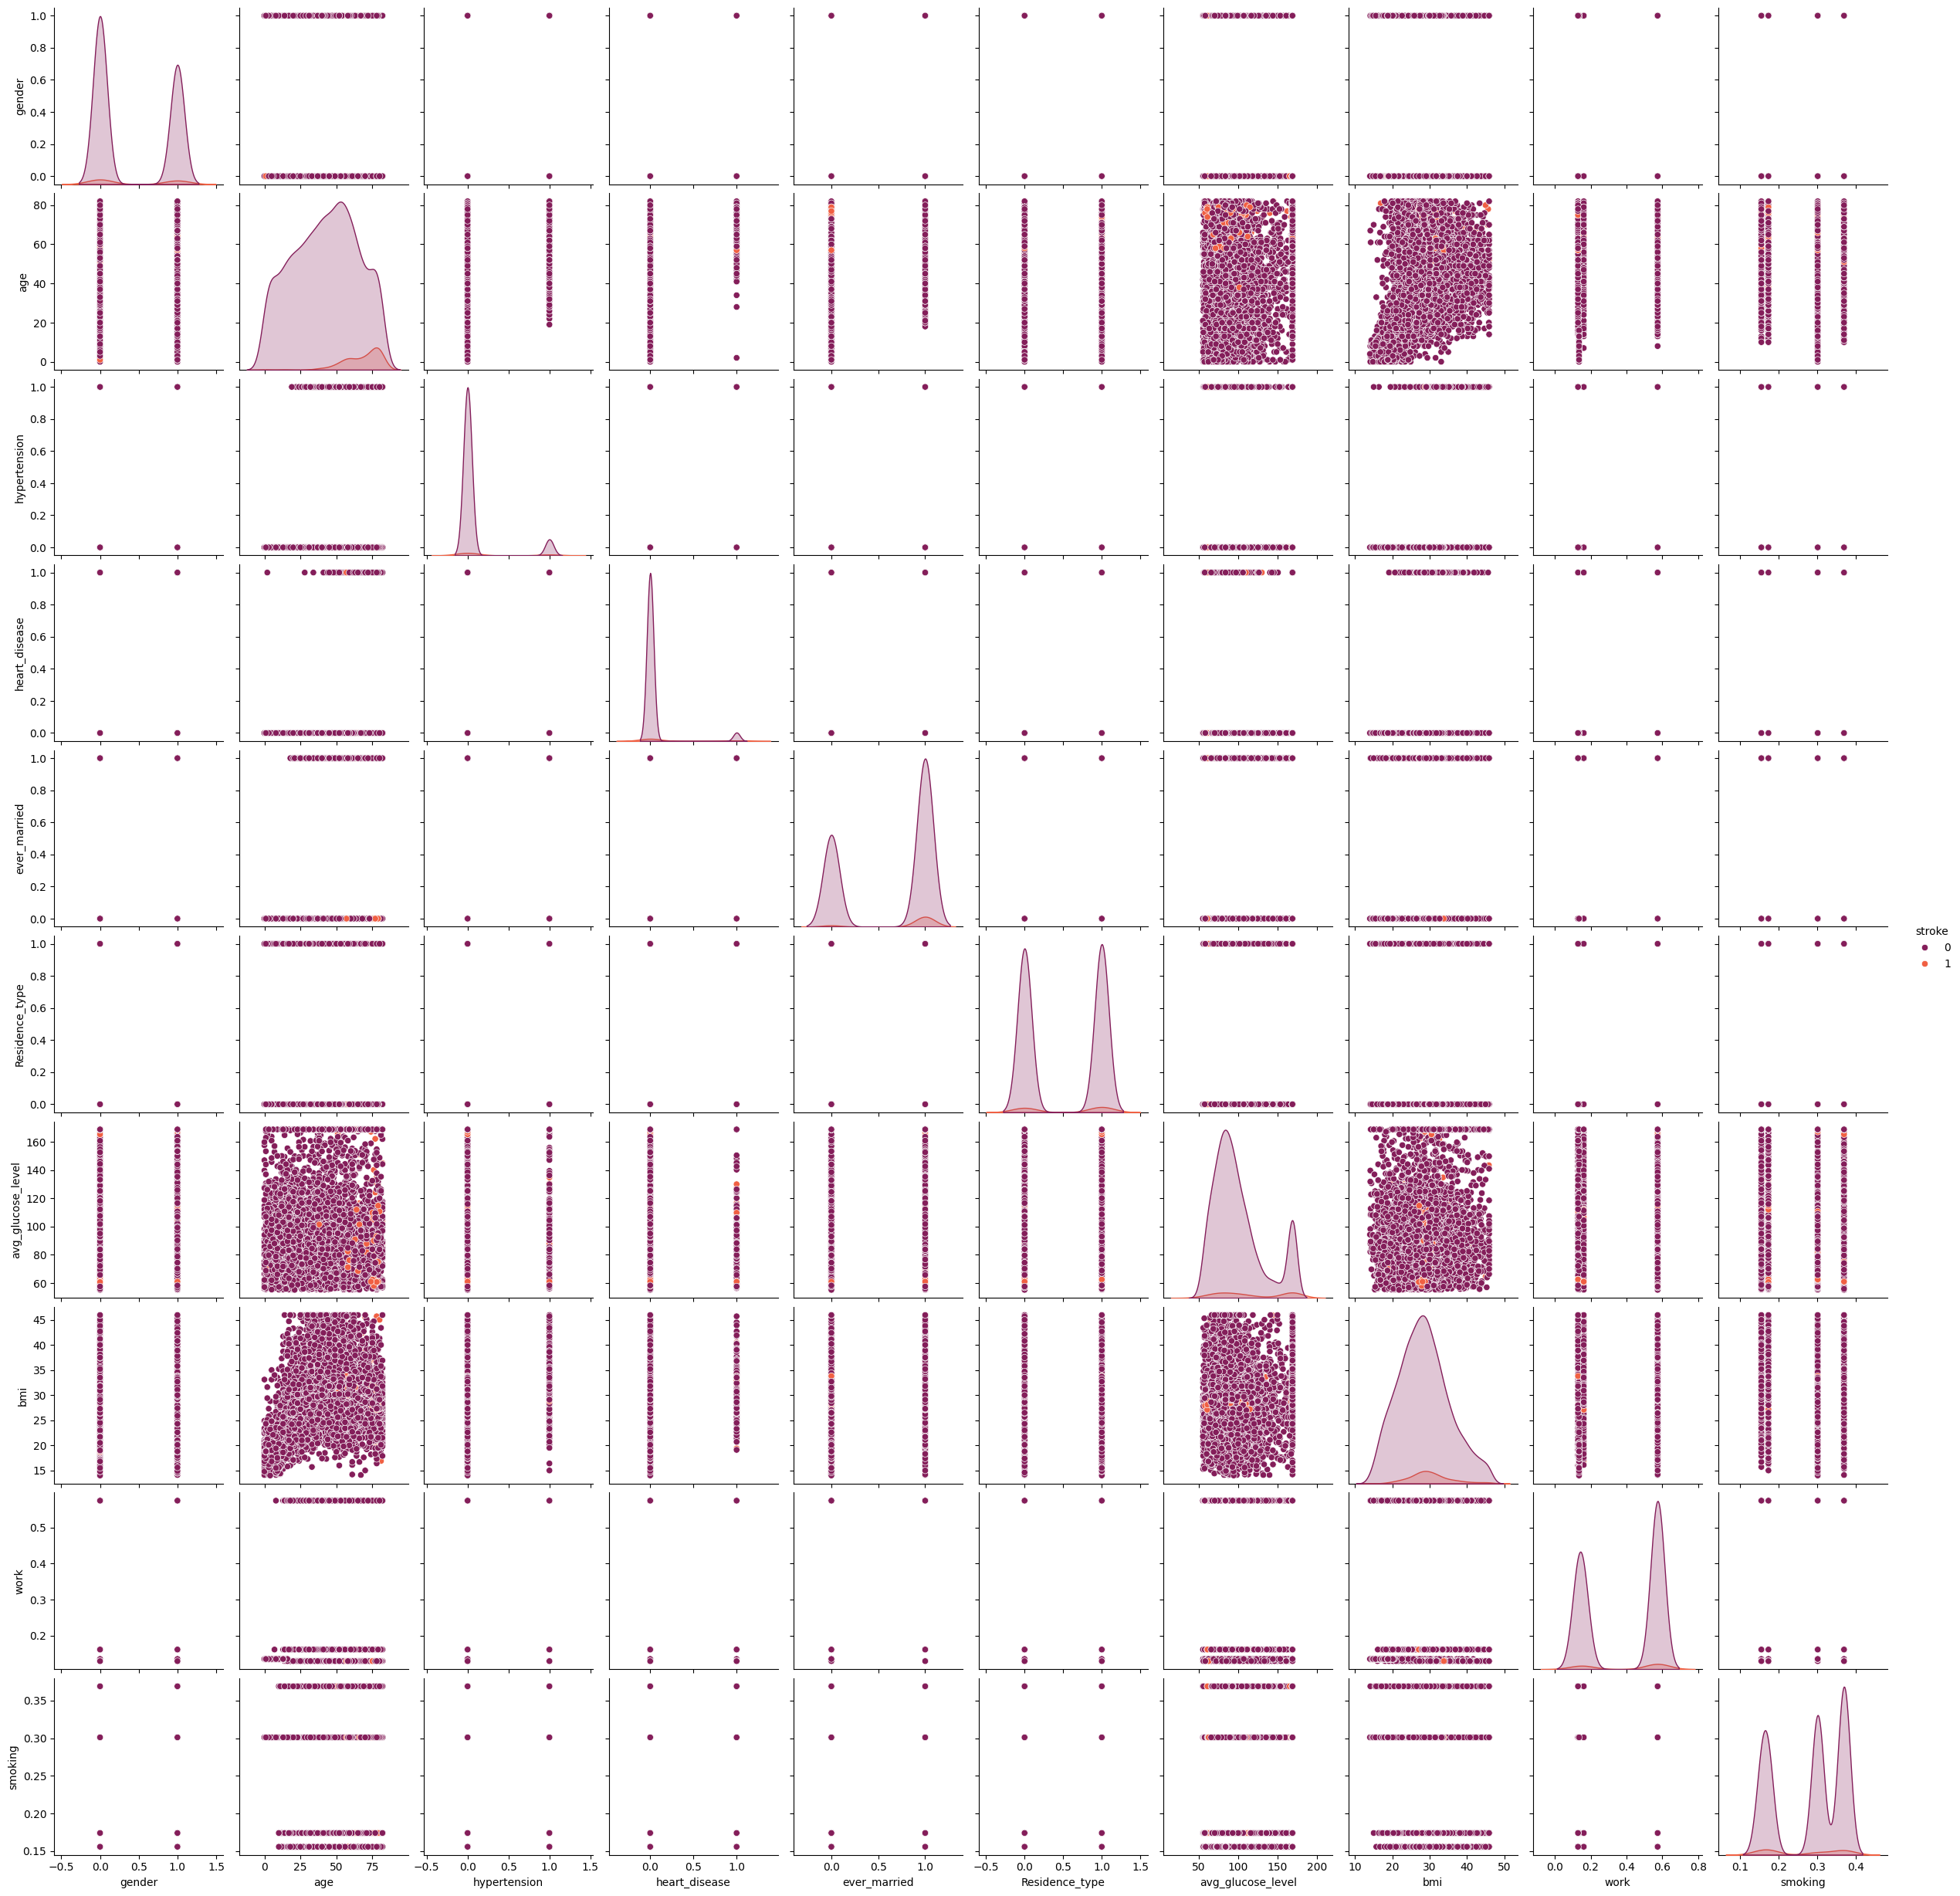

In [29]:
#Pair plot en fonction du label

sns.pairplot(data=data, hue='stroke', palette='rocket')

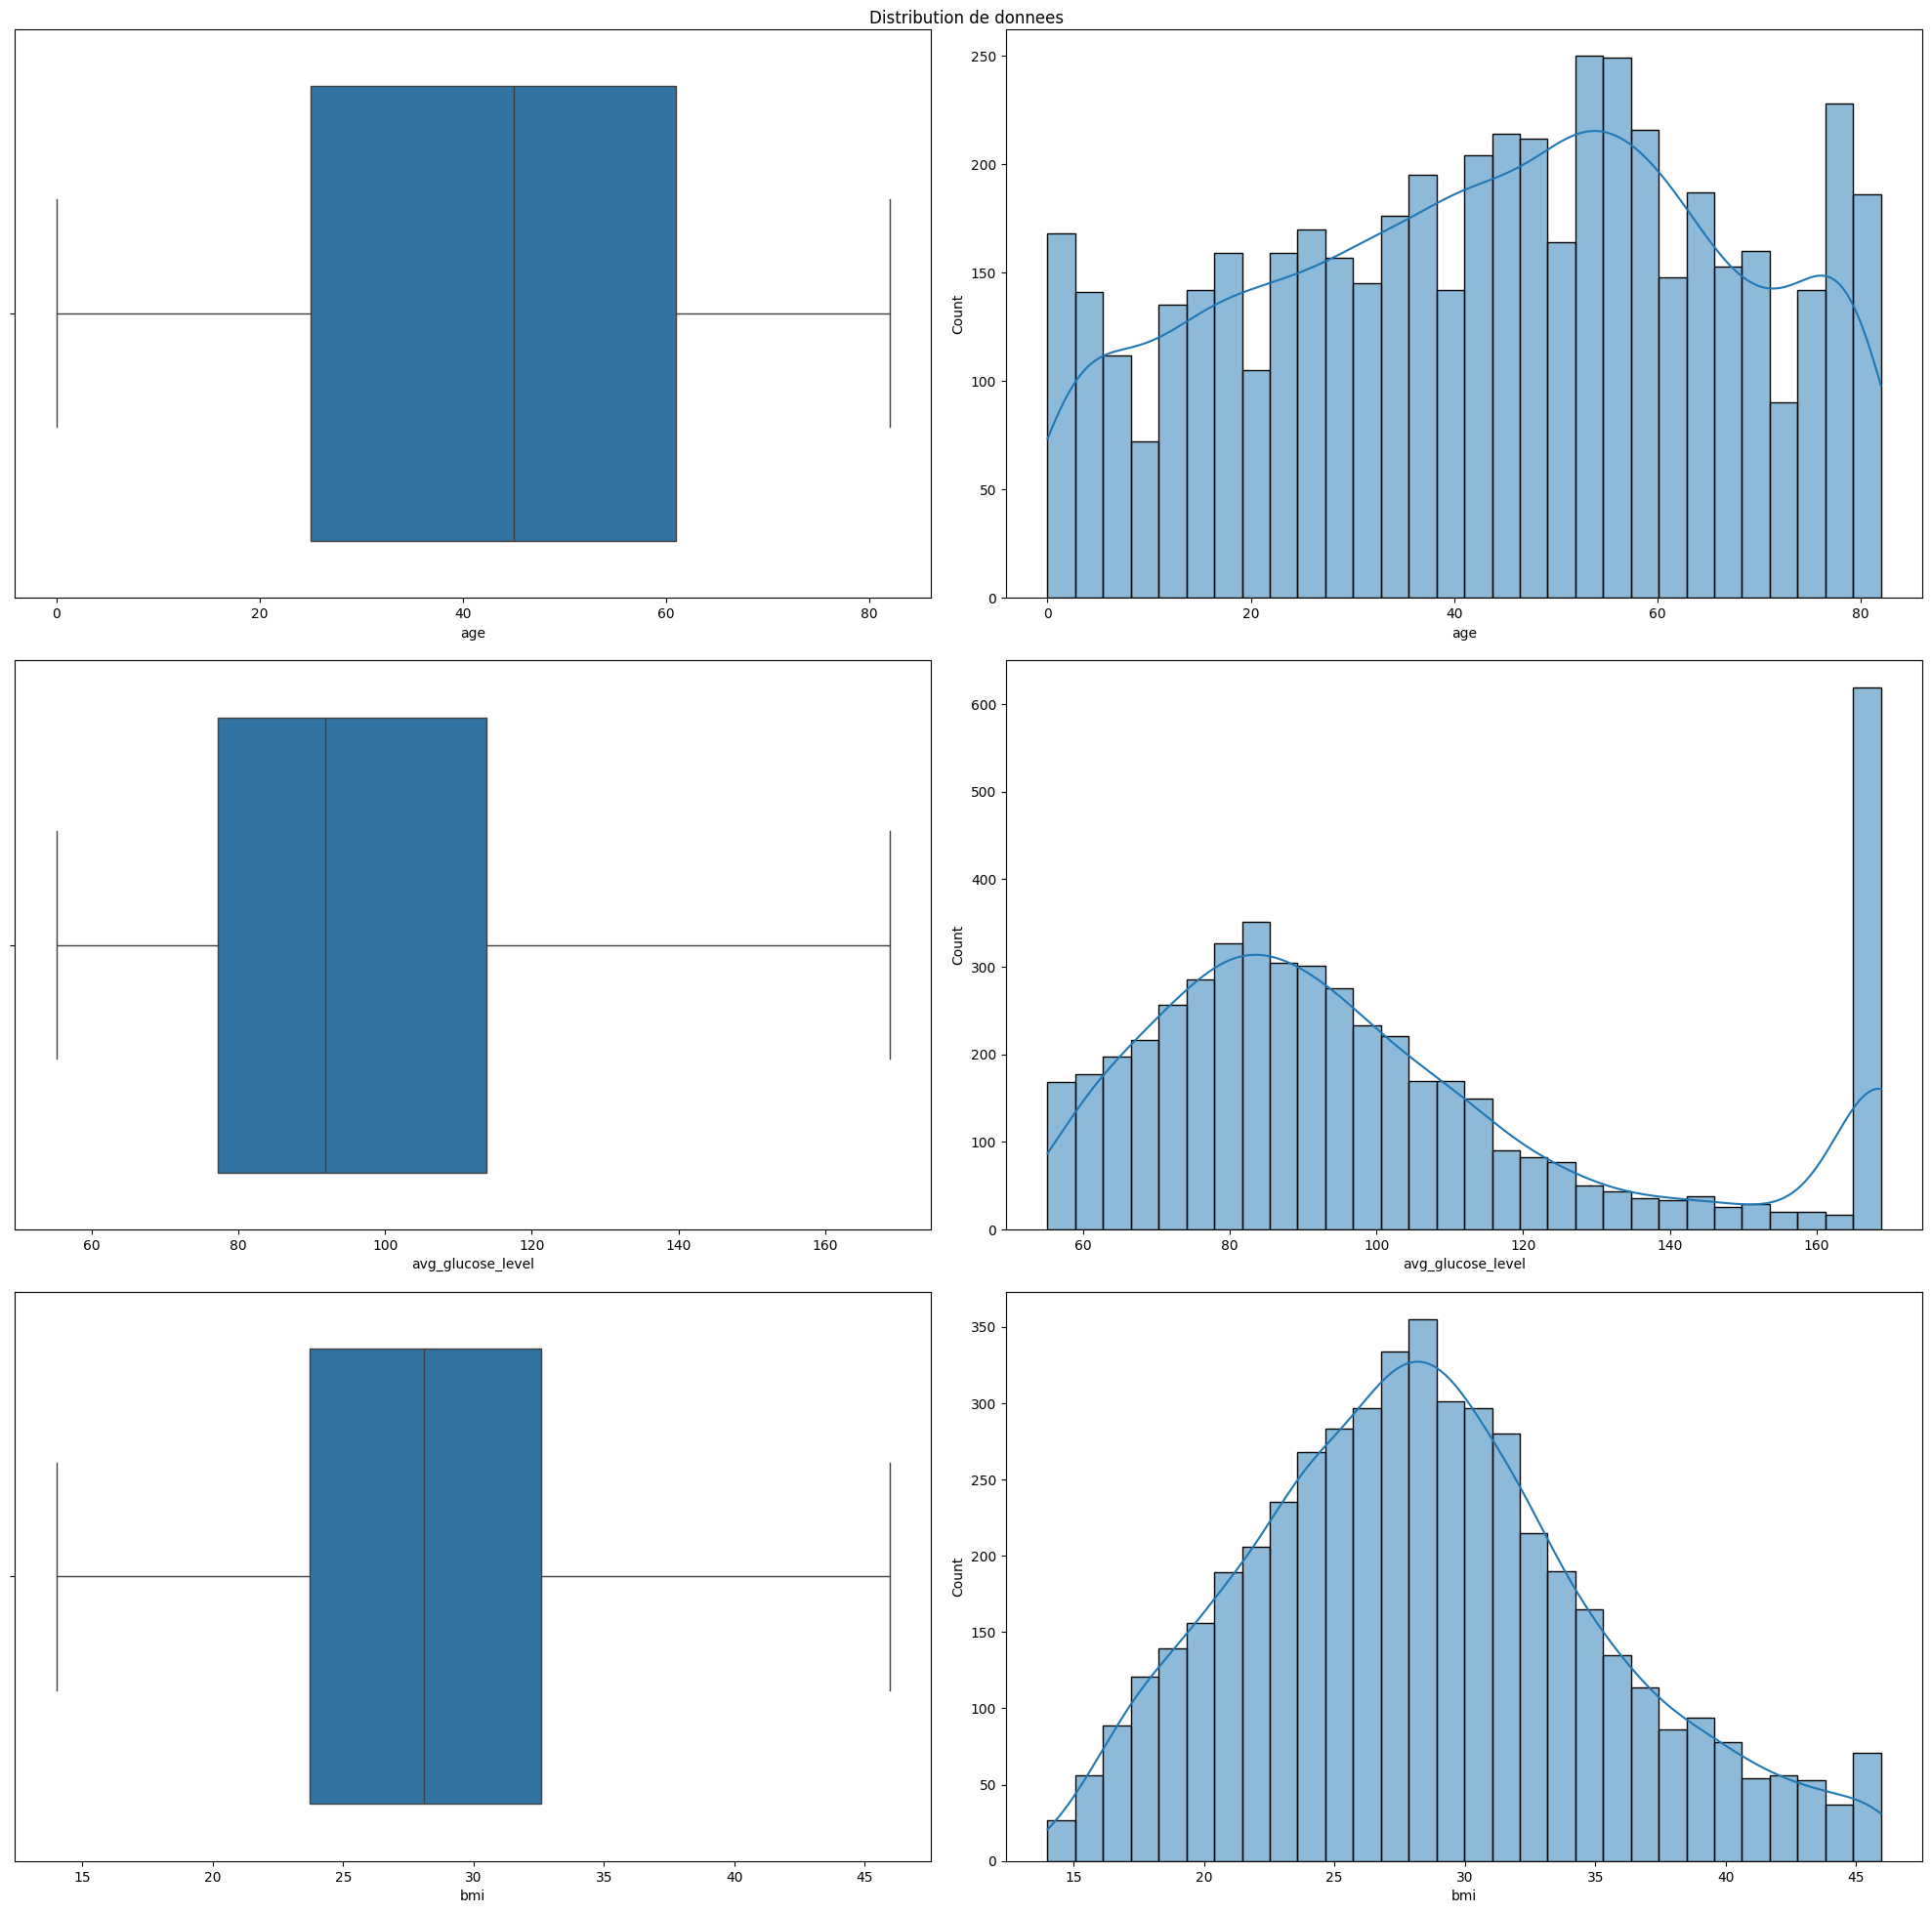

In [30]:
num_col= ['age','avg_glucose_level','bmi']

fig, ax = plt.subplots(ncols=2,nrows=len(num_col),figsize=(20,20))
for i in enumerate(num_col):
    sns.boxplot(x=data[i[1]],ax=ax[i[0]][0])
    sns.histplot(x=data[i[1]],kde=True,bins=30,ax=ax[i[0]][1])

fig.suptitle("Distribution de donnees")
sns.set_context(font_scale=5)
plt.tight_layout(pad=1.5)
plt.show()

In [31]:
data.head()

,gender,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,stroke,work,smoking
0,1,67,0,1,1,1,168.805,36.6,1,0.574182,0.174061
1,1,80,0,1,1,0,105.920,32.5,1,0.574182,0.369002
2,0,49,0,0,1,1,168.805,34.4,1,0.574182,0.155792
3,0,79,1,0,1,0,168.805,24.0,1,0.161413,0.369002
4,1,81,0,0,1,1,168.805,29.0,1,0.574182,0.174061


In [32]:
X = data.drop(['stroke'],axis=1)
y = data[['stroke']]

In [33]:

#Separation des donnees d'entrainements et de tests (80% entrainements 20% tests)

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2, random_state=0)

In [34]:
# observons X_train
X_train

,gender,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,work,smoking
4606,0,71,0,0,1,1,168.805,31.8,0.161413,0.174061
1338,0,78,0,0,1,0,154.750,17.6,0.574182,0.369002
2782,0,57,0,0,1,0,95.360,32.4,0.161413,0.174061
1471,0,15,0,0,0,1,81.110,20.2,0.135113,0.301144
829,0,63,0,0,1,1,96.260,31.8,0.574182,0.301144
...,...,...,...,...,...,...,...,...,...,...
4931,1,60,0,0,1,0,168.805,33.5,0.161413,0.301144
3264,1,49,0,0,1,0,78.340,32.5,0.574182,0.301144
1653,0,56,0,0,1,1,168.805,42.8,0.161413,0.369002
2607,1,57,0,0,1,1,107.490,29.5,0.574182,0.369002


In [35]:
#STANTARDISATION (FEATURE SCALING) (pour gerer l'ecart entre les variables)

from sklearn.preprocessing import StandardScaler
sc= StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

In [36]:
X_train

array([[-0.84908794,  1.21278083, -0.3284778 , ...,  0.49498316,
        -1.0648752 , -1.24777996],
       [-0.84908794,  1.52124654, -0.3284778 , ..., -1.60942995,
         0.86810371,  1.01777734],
       [-0.84908794,  0.5958494 , -0.3284778 , ...,  0.58390203,
        -1.0648752 , -1.24777996],
       ...,
       [-0.84908794,  0.55178287, -0.3284778 , ...,  2.12516233,
        -1.0648752 ,  1.01777734],
       [ 1.17773432,  0.5958494 , -0.3284778 , ...,  0.15412752,
         0.86810371,  1.01777734],
       [-0.84908794, -1.51934407, -0.3284778 , ..., -1.44641203,
        -1.1880368 ,  0.22914874]])

In [37]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
clf = RandomForestClassifier()
clf.fit(X_train, y_train)


C:\Users\COMPUTER CARE\AppData\Roaming\Python\Python311\site-packages\sklearn\base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestClassifier()

<Axes: >

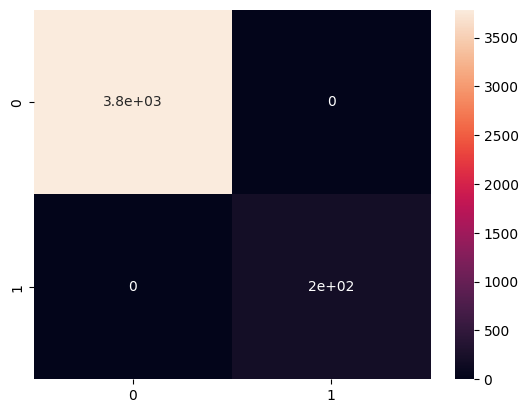

In [38]:
#matrice de confusion

from sklearn.metrics import accuracy_score,confusion_matrix
y_predict_train=clf.predict(X_train)
confMat = confusion_matrix(y_train,y_predict_train)

#affichons le matrice de confusion
sns.heatmap(confMat, annot=True)

In [39]:
#ACCURACY SCORE

print('accuracy_score_train=', accuracy_score(y_train,y_predict_train))

print('F1 SCORE: =',f1_score(y_train,y_predict_train))

accuracy_score_train= 1.0
F1 SCORE: = 1.0


In [40]:
print(classification_report(y_train, y_predict_train))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3786
           1       1.00      1.00      1.00       198

    accuracy                           1.00      3984
   macro avg       1.00      1.00      1.00      3984
weighted avg       1.00      1.00      1.00      3984



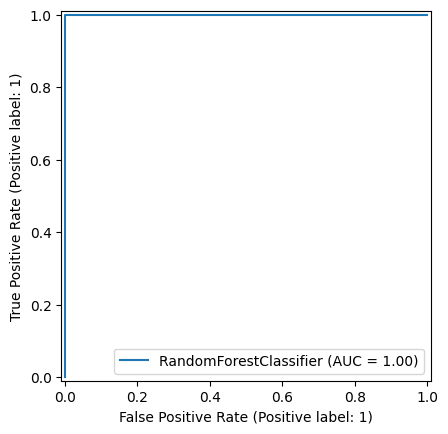

In [41]:
#courbe ROC train

from sklearn.metrics import RocCurveDisplay
classifier_disp=RocCurveDisplay.from_estimator(clf,X_train,y_train)

In [42]:
from sklearn.metrics import roc_auc_score
auc = roc_auc_score(y_train, y_predict_train)
print('AUC TRAIN:', auc)

AUC TRAIN: 1.0


<Axes: >

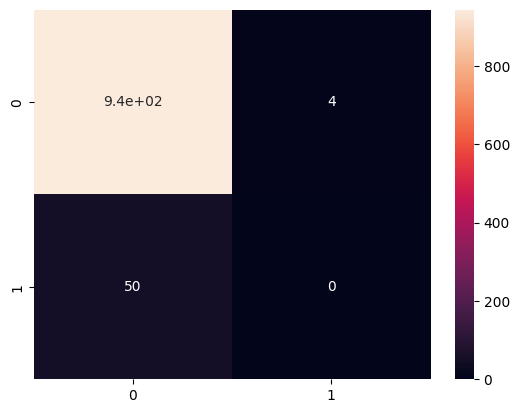

In [43]:
#matrice de confusion pour les donnees de test

y_predict_test=clf.predict(X_test)
cmt = confusion_matrix(y_test,y_predict_test)

#affichons le matrice de confusion du test

sns.heatmap(cmt, annot=True)


In [44]:
#accuracy_score des donnees de test

print('accuracy_score_test:', accuracy_score(y_test,y_predict_test))

#F1 score du test

f1 = f1_score(y_test,y_predict_test)
print('F1_SCORE TEST:', f1)

# AUC
auc = roc_auc_score(y_test, y_predict_test)
print('AUC TEST:', auc)

accuracy_score_test: 0.9458375125376128
F1_SCORE TEST: 0.0
AUC TEST: 0.4978880675818374


In [45]:
#calcul des differents parametres(precision, recall, f1-score,support) des donnees de test

print(classification_report(y_test,y_predict_test))

              precision    recall  f1-score   support

           0       0.95      1.00      0.97       947
           1       0.00      0.00      0.00        50

    accuracy                           0.95       997
   macro avg       0.47      0.50      0.49       997
weighted avg       0.90      0.95      0.92       997



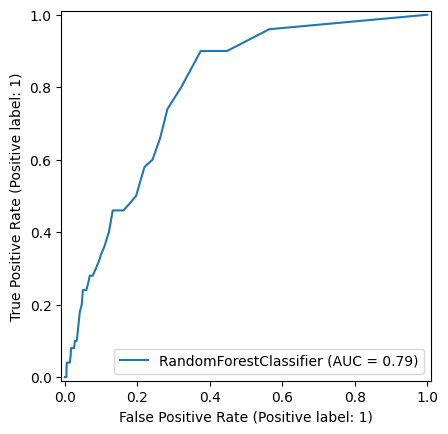

In [46]:
#courbe ROC test

classifier_disp=RocCurveDisplay.from_estimator(clf,X_test,y_test)

In [47]:
#Algo de classification KNN
from sklearn.neighbors import KNeighborsClassifier
classifier = KNeighborsClassifier(n_neighbors=5)
classifier.fit(X_train,y_train)

C:\Users\COMPUTER CARE\AppData\Roaming\Python\Python311\site-packages\sklearn\neighbors\_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


KNeighborsClassifier()

In [48]:
from sklearn.metrics import accuracy_score,confusion_matrix
y_predict_train=classifier.predict(X_train)

print('accuracy_score:', accuracy_score(y_train,y_predict_train))


accuracy_score: 0.9525602409638554


<Axes: >

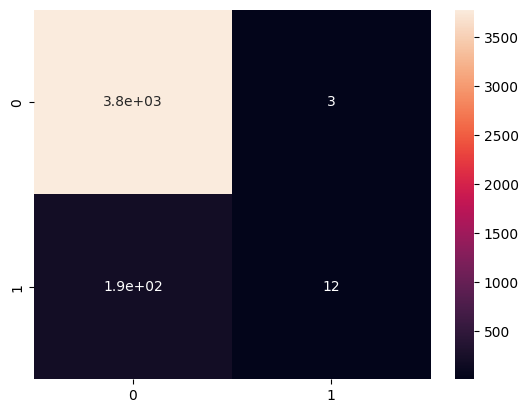

In [49]:
## MATRICE DE CONFUSION DU TRAIN

cmt = confusion_matrix(y_train,y_predict_train)
#affichons le matrice de confusion
sns.heatmap(cmt, annot=True)

In [50]:
from sklearn.metrics import classification_report
print(classification_report(y_train,y_predict_train))

              precision    recall  f1-score   support

           0       0.95      1.00      0.98      3786
           1       0.80      0.06      0.11       198

    accuracy                           0.95      3984
   macro avg       0.88      0.53      0.54      3984
weighted avg       0.95      0.95      0.93      3984



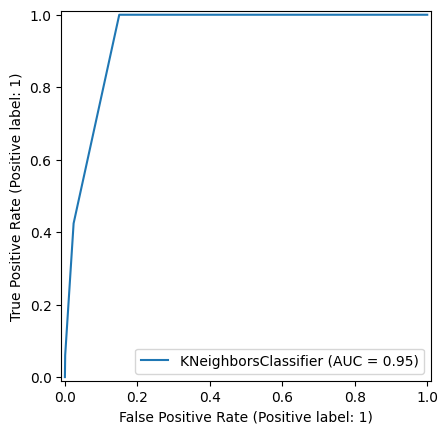

In [51]:
#courbe ROC
from sklearn.metrics import RocCurveDisplay
classifier_disp=RocCurveDisplay.from_estimator(classifier,X_train,y_train)

In [52]:
y_predict_test=classifier.predict(X_test)
cmt = confusion_matrix(y_test,y_predict_test)
print('accuracy_score_test:', accuracy_score(y_test,y_predict_test))

accuracy_score_test: 0.9468405215646941


In [53]:
# classification report test

print(classification_report(y_test,y_predict_test))

              precision    recall  f1-score   support

           0       0.95      1.00      0.97       947
           1       0.00      0.00      0.00        50

    accuracy                           0.95       997
   macro avg       0.47      0.50      0.49       997
weighted avg       0.90      0.95      0.92       997



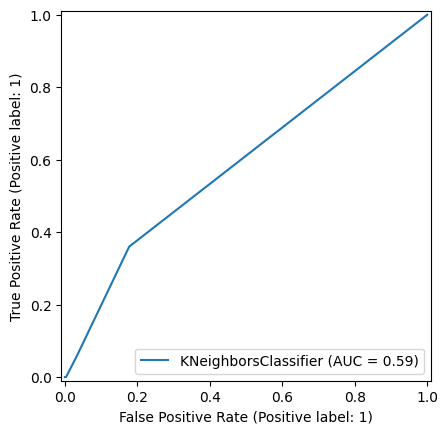

In [54]:
from sklearn.metrics import RocCurveDisplay
classifier_disp=RocCurveDisplay.from_estimator(classifier,X_test,y_test)

In [55]:
import xgboost as xgb

 # Create an XGBoost classifier
model = xgb.XGBClassifier()
# entrainement
model.fit(X_train, y_train)

#Prediction
y_predict = model.predict(X_test)

# Evaluation du model
accuracy = clf.score(X_test, y_test)
print("Accuracy:", accuracy)

Accuracy: 0.9458375125376128


In [56]:
#DEFINITION DES HYPERPARAMETRES ( 3 hyperparametres et 2 elements par hyperparametres)

param_grid = {'n_estimators':[100,200],
            'max_depth':[15,20],
            'learning_rate': [0.1, 0.05]}

In [58]:
model= xgb.XGBClassifier()

In [59]:
#Recherche gridSearch
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(estimator=model, param_grid= param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train,y_train)

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None,...
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=None, ...),
             param_grid={'learning_rate': [0.1, 0.05], 'max_depth': [15, 20],
                         'n_estimators': [100, 200]},
             scoring='accuracy')

In [60]:
#Recuperation des meilleurs hyperparametres

best_params= grid_search.best_params_
best_score= grid_search.best_score_


In [61]:
#affichage des meilleurs parametres et scores

print('MEILLEURS PARAMETRES:', best_params)
print('MEILLEURS SCORES:', best_score)

MEILLEURS PARAMETRES: {'learning_rate': 0.05, 'max_depth': 20, 'n_estimators': 100}
MEILLEURS SCORES: 0.9452803540916628
